<h1 style="text-align:center; color: blue;">AUGUSTINA AGYAPOMAA AGYEMAN</h1>
<h2 style="text-align:center; color: green;">PROJECT 1</h2>
<h3 style="text-align:center; color: orange;">SUPERVISOR: Obeng Dominic Koranteng, ODK SOLUTIONS HUB</h3>

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

In [2]:
# Read the dataset
DATA_PATH = Path("/content/student_math_clean.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


<h2 style="text-align:center; color: green;">EDA</h2>

In [3]:
# Dataset dimensions (rows, columns)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Rows: 395 | Columns: 34


In [5]:
# Checking for missing values in the dataset
missing = df.isna().sum().sum()
print(f"Total missing values: {missing}")

Total missing values: 0


In [6]:
# Displaying the names of the features
df.columns

Index(['student_id', 'school', 'sex', 'age', 'address_type', 'family_size',
       'parent_status', 'mother_education', 'father_education', 'mother_job',
       'father_job', 'school_choice_reason', 'guardian', 'travel_time',
       'study_time', 'class_failures', 'school_support', 'family_support',
       'extra_paid_classes', 'activities', 'nursery_school', 'higher_ed',
       'internet_access', 'romantic_relationship', 'family_relationship',
       'free_time', 'social', 'weekday_alcohol', 'weekend_alcohol', 'health',
       'absences', 'grade_1', 'grade_2', 'final_grade'],
      dtype='object')

In [7]:
# Selecting unique observations for the target (final_grade)
df["final_grade"].unique()

array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4])

In [8]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             395 non-null    int64 
 1   school                 395 non-null    object
 2   sex                    395 non-null    object
 3   age                    395 non-null    int64 
 4   address_type           395 non-null    object
 5   family_size            395 non-null    object
 6   parent_status          395 non-null    object
 7   mother_education       395 non-null    object
 8   father_education       395 non-null    object
 9   mother_job             395 non-null    object
 10  father_job             395 non-null    object
 11  school_choice_reason   395 non-null    object
 12  guardian               395 non-null    object
 13  travel_time            395 non-null    object
 14  study_time             395 non-null    object
 15  class_failures         

In [9]:
# Describing the dataset
df.describe()

,student_id,age,class_failures,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,198.000000,16.696203,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,114.170924,1.276043,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,99.500000,16.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,198.000000,17.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,296.500000,18.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,395.000000,22.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


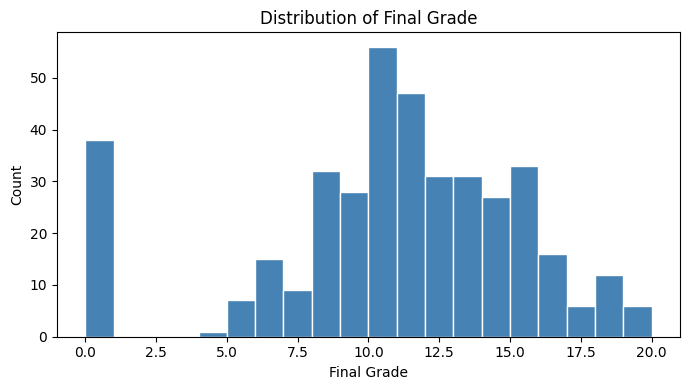

In [10]:
# NEW: Distribution of the raw target (final_grade)
plt.figure(figsize=(7, 4))
plt.hist(df["final_grade"], bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.title("Distribution of Final Grade")
plt.tight_layout()
plt.savefig("Final_Grade_Distribution.png", bbox_inches="tight")
plt.show()

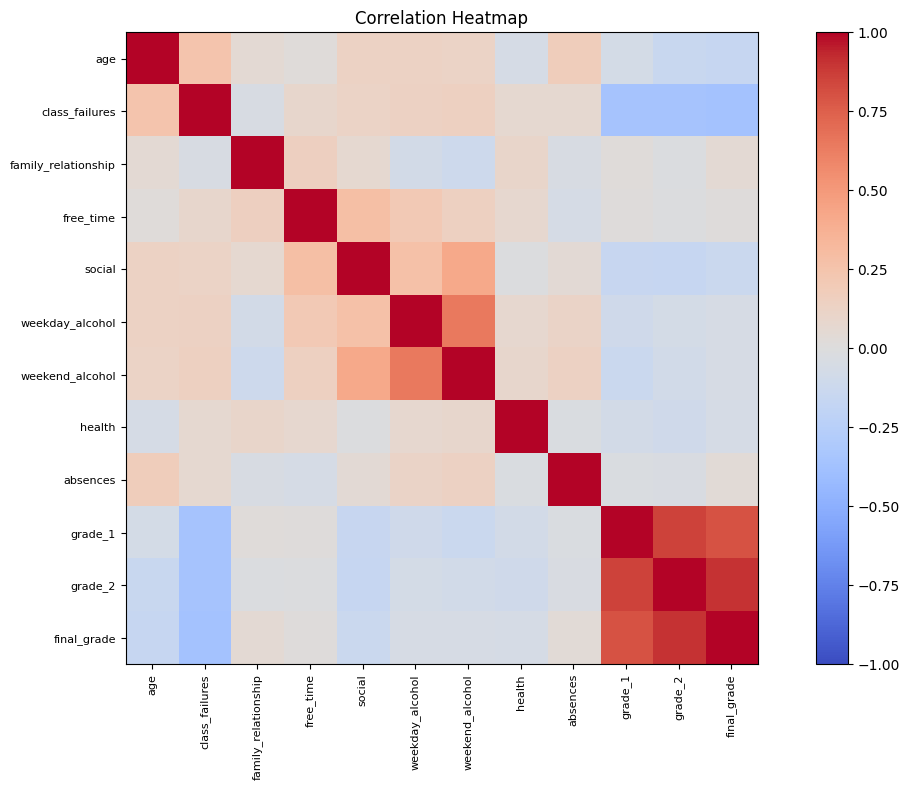

In [12]:
# NEW: Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include="number").drop(columns=["student_id"], errors="ignore")
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Correlation_Heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
# Classifying the target into three groups
# Thresholds follow a typical 0-20 Portuguese grading scale:
#   0-9  → Pass (bare pass / fail zone)
#  10-15 → 2nd_Class (satisfactory to good)
#  16-20 → 1st_Class (very good to excellent)

def gpa_category(gpa):
    if gpa <= 9:
        return "Pass"
    elif gpa <= 15:
        return "2nd_Class"
    else:
        return "1st_Class"

df["GPA_Category"] = df["final_grade"].apply(gpa_category)
print(df["GPA_Category"].value_counts())

GPA_Category
2nd_Class    225
Pass         130
1st_Class     40
Name: count, dtype: int64


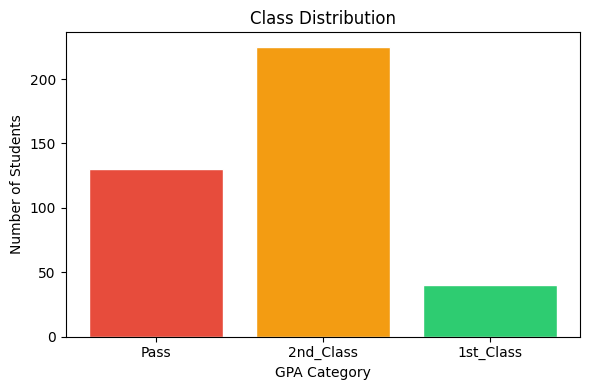

In [14]:
# Class distribution: important to spot class imbalance before modelling
class_order = ["Pass", "2nd_Class", "1st_Class"]
counts = df["GPA_Category"].value_counts().reindex(class_order)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=["#e74c3c", "#f39c12", "#2ecc71"], edgecolor="white")
plt.xlabel("GPA Category")
plt.ylabel("Number of Students")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("Class_Distribution.png", bbox_inches="tight")
plt.show()

In [15]:
# Setting the target and dropping it from features to avoid data leakage
target = "GPA_Category"

X = df.drop(columns=["final_grade", "GPA_Category", "student_id"])
y = df[target]

In [16]:
# Encoding the target label
# LabelEncoder assigns classes alphabetically:
#   1st_Class → 0 | 2nd_Class → 1 | Pass → 2
# We store le_y so we can recover the correct class names in plots later.

le_y = LabelEncoder()
y = le_y.fit_transform(y)
print("Class mapping:", dict(zip(le_y.classes_, le_y.transform(le_y.classes_))))

Class mapping: {'1st_Class': np.int64(0), '2nd_Class': np.int64(1), 'Pass': np.int64(2)}


In [17]:
# One-hot encode categorical features.
# drop_first=True removes one dummy per group to avoid multicollinearity.
X = pd.get_dummies(X, drop_first=True)

In [18]:
# Stratified split preserves class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<h2 style="text-align:center; color: green;">Models</h2>

In [19]:
# Using a Pipeline prevents data leakage, the scaler is fit only on training
# data and applied consistently to the test set.

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le_y.classes_))

# Cross-validation (5-fold, stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring="accuracy")
print(f"CV Accuracy: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

# ROC-AUC (One-vs-Rest for multiclass)
lr_proba = lr_pipeline.predict_proba(X_test)
lr_roc_auc = roc_auc_score(y_test, lr_proba, multi_class="ovr", average="weighted")
print(f"ROC-AUC (weighted OvR): {lr_roc_auc:.4f}")

=== Logistic Regression ===
Accuracy: 0.7974683544303798
[[ 4  4  0]
 [ 7 37  1]
 [ 0  4 22]]
              precision    recall  f1-score   support

   1st_Class       0.36      0.50      0.42         8
   2nd_Class       0.82      0.82      0.82        45
        Pass       0.96      0.85      0.90        26

    accuracy                           0.80        79
   macro avg       0.71      0.72      0.71        79
weighted avg       0.82      0.80      0.81        79

CV Accuracy: 0.8329 ± 0.0539
ROC-AUC (weighted OvR): 0.8951


In [20]:
# Random Forest — tree-based models are scale-invariant so no scaler needed

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le_y.classes_))

# Cross-validation
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="accuracy")
print(f"CV Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# ROC-AUC
rf_proba = rf.predict_proba(X_test)
rf_roc_auc = roc_auc_score(y_test, rf_proba, multi_class="ovr", average="weighted")
print(f"ROC-AUC (weighted OvR): {rf_roc_auc:.4f}")

=== Random Forest ===
Accuracy: 0.8860759493670886
              precision    recall  f1-score   support

   1st_Class       0.71      0.62      0.67         8
   2nd_Class       0.89      0.91      0.90        45
        Pass       0.92      0.92      0.92        26

    accuracy                           0.89        79
   macro avg       0.84      0.82      0.83        79
weighted avg       0.88      0.89      0.88        79

CV Accuracy: 0.8481 ± 0.0543
ROC-AUC (weighted OvR): 0.9401


In [23]:
# Side-by-side model comparison
comparison = pd.DataFrame({
    "Model":          ["Logistic Regression", "Random Forest"],
    "Test Accuracy":  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    "CV Accuracy":    [lr_cv_scores.mean(),                rf_cv_scores.mean()],
    "CV Std":         [lr_cv_scores.std(),                 rf_cv_scores.std()],
    "ROC-AUC (OvR)": [lr_roc_auc,                         rf_roc_auc],
})
comparison.set_index("Model", inplace=True)
comparison.round(4)

,Test Accuracy,CV Accuracy,CV Std,ROC-AUC (OvR)
Model,,,,
Logistic Regression,0.7975,0.8329,0.0539,0.8951
Random Forest,0.8861,0.8481,0.0543,0.9401


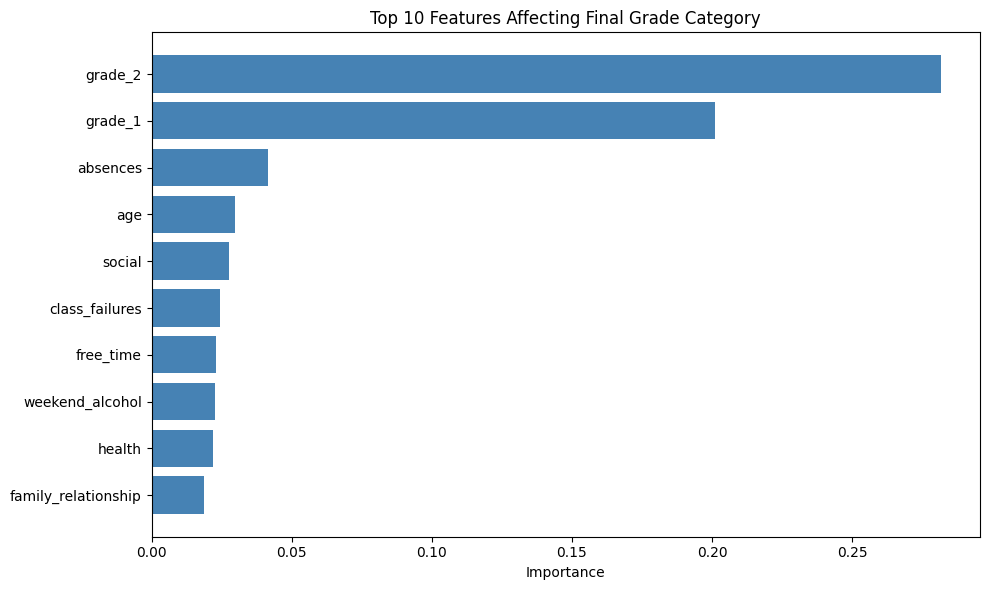

In [24]:
# Feature Importance

importances = rf.feature_importances_
indices     = np.argsort(importances)          # ascending → most important last
top_idx     = indices[-10:]                    # top 10
features    = np.array(X.columns)

plt.figure(figsize=(10, 6))
plt.barh(features[top_idx], importances[top_idx], color="steelblue")
plt.xlabel("Importance")
plt.title("Top 10 Features Affecting Final Grade Category")
plt.tight_layout()
plt.savefig("Features_Affecting_Final_Grade.png", bbox_inches="tight")
plt.show()

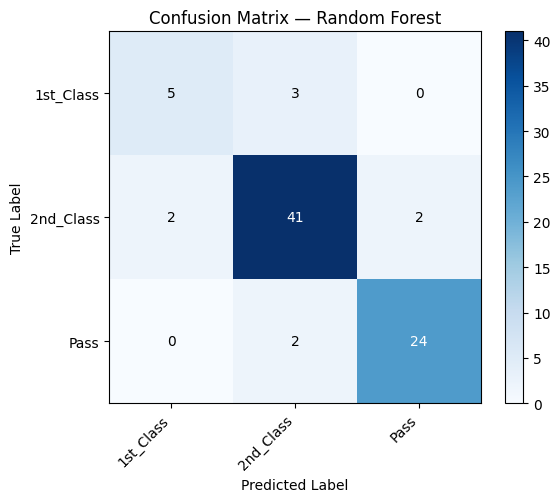

In [25]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)
classes = le_y.classes_          # ['1st_Class', '2nd_Class', 'Pass']

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)), classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig("Confusion_Matrix.png", bbox_inches="tight")
plt.show()

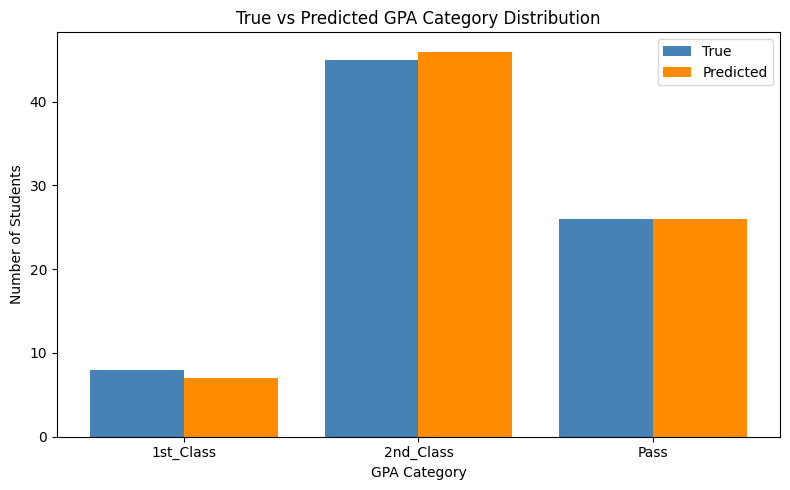

In [28]:
# Category distribution

n_classes   = len(le_y.classes_)
true_counts = np.bincount(y_test,      minlength=n_classes)
pred_counts = np.bincount(y_pred_rf,   minlength=n_classes)

x = np.arange(n_classes)

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, true_counts, width=0.4, label="True",      color="steelblue")
plt.bar(x + 0.2, pred_counts, width=0.4, label="Predicted", color="darkorange")

plt.xticks(x, le_y.classes_)
plt.xlabel("GPA Category")
plt.ylabel("Number of Students")
plt.title("True vs Predicted GPA Category Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("True_vs_Predicted_Distribution.png", bbox_inches="tight")
plt.show()